In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import polars as pl
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn import set_config
from sklearn.model_selection import StratifiedKFold
import ctypes
import cloudpickle as cp
import gc
import os
import warnings
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names"
)

import matplotlib.pyplot as plt

import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_slice,
    plot_param_importances
)
%pip install optuna-integration[lightgbm]

set_config(display='diagram')
%matplotlib inline


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 3.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
def amex_metric_np(target: np.ndarray, preds: np.ndarray) -> float:
    indices = np.argsort(preds)[::-1]
    preds, target = preds[indices], target[indices]

    weight = 20.0 - target * 19.0
    cum_norm_weight = (weight / weight.sum()).cumsum()
    four_pct_mask = cum_norm_weight <= 0.04
    d = np.sum(target[four_pct_mask]) / np.sum(target)

    weighted_target = target * weight
    lorentz = (weighted_target / weighted_target.sum()).cumsum()
    gini = ((lorentz - cum_norm_weight) * weight).sum()

    n_pos = np.sum(target)
    n_neg = target.shape[0] - n_pos
    gini_max = 10 * n_neg * (n_pos + 20 * n_neg - 19) / (n_pos + 20 * n_neg)

    g = gini / gini_max
    return 0.5 * (g + d)

def lgb_amex_metric(y_true, y_pred):
    """The competition metric with lightgbm's calling convention"""
    return ('amex',
            amex_metric_np(y_true, y_pred),
            True)
    
def release_memory():
    gc.collect()
    ctypes.CDLL("libc.so.6").malloc_trim(0)

In [3]:
train = pl.read_parquet("/kaggle/input/datasets/analyticgentleman/gold-data/train_data")

feature_names = train.drop(["customer_ID","target"]).columns

X = train.drop(["customer_ID", "target"]).to_numpy()
y = train["target"].to_numpy()

del train
release_memory()

In [4]:
def lgbm_classifier_search_space(trial):

    return {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1,
        "n_estimators": 2000,

        # tree complexity (centered around best trial)
        "num_leaves": trial.suggest_int("num_leaves", 150, 350), # increased num leaves range from 100-300 to 150-350
        "max_depth": trial.suggest_int("max_depth", 8, 16),

        # learning rate
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.025, 0.06, log=True
        ),
        
        # regularization
        "min_child_samples": trial.suggest_int("min_child_samples",200, 260), # increased minimum child samples lower bound to 200 and upper bound to 260

        "min_child_weight": trial.suggest_float(
            "min_child_weight", 1e-3, 1.0, log=True
        ),

        # sampling
        "subsample": trial.suggest_float("subsample",0.9, 1.0), # increased lower bound from 0.7 to 0.9
        "subsample_freq": trial.suggest_int("subsample_freq",10, 15), # range changed from 7-12 to 10-15.

        "colsample_bytree": trial.suggest_float("colsample_bytree",0.85, 1.0),

        # regularization
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 0.5, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.3, 3.0, log=True),# increased lower bound from 0.1 to 0.3

        "min_split_gain": trial.suggest_float("min_split_gain",0.0, 0.2),

        # imbalance
        "scale_pos_weight": trial.suggest_float("scale_pos_weight",4.0, 7.0),

        # allow near trial 3 but prevent explosion
        "max_bin": trial.suggest_int("max_bin",200, 400),
    }

In [5]:
def objective_tree(trial):
    params = lgbm_classifier_search_space(trial)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_idx, val_idx = next(iter(skf.split(X, y)))

    pruning_callback = optuna.integration.LightGBMPruningCallback(trial, "amex")

    model = LGBMClassifier(**params)
    model.fit(
        X[train_idx],
        y[train_idx],
        feature_name=feature_names,
        eval_set=[(X[val_idx], y[val_idx])],
        eval_metric=[lgb_amex_metric],
        callbacks=[
            lgb.early_stopping(stopping_rounds=30),
            lgb.log_evaluation(period=100),
            pruning_callback
        ]
    )
    preds = model.predict(X[val_idx], raw_score=True)
    return amex_metric_np(y[val_idx], preds)

# Use MedianPruner — kills trials performing below median at any checkpoint
release_memory()
study_tree = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=4, n_warmup_steps=100)
)

study_tree.optimize(objective_tree, n_trials=30)

[I 2026-04-10 03:40:53,678] A new study created in memory with name: no-name-0f0321e3-24f7-4e3d-8c70-17bfb7112636


Training until validation scores don't improve for 30 rounds
[100]	valid_0's auc: 0.958848	valid_0's amex: 0.782743
[200]	valid_0's auc: 0.961271	valid_0's amex: 0.795223
Early stopping, best iteration is:
[269]	valid_0's auc: 0.961851	valid_0's amex: 0.797991


[I 2026-04-10 03:53:41,964] Trial 0 finished with value: 0.7977509148947713 and parameters: {'num_leaves': 237, 'max_depth': 8, 'learning_rate': 0.04328037731736363, 'min_child_samples': 219, 'min_child_weight': 0.009122284173376566, 'subsample': 0.9324853217170884, 'subsample_freq': 12, 'colsample_bytree': 0.988277022997318, 'reg_alpha': 0.08044772953222591, 'reg_lambda': 1.885954095216504, 'min_split_gain': 0.16051902347265004, 'scale_pos_weight': 4.738523351285514, 'max_bin': 201}. Best is trial 0 with value: 0.7977509148947713.


Training until validation scores don't improve for 30 rounds
[100]	valid_0's auc: 0.95957	valid_0's amex: 0.786305
[200]	valid_0's auc: 0.961486	valid_0's amex: 0.794491
[300]	valid_0's auc: 0.962034	valid_0's amex: 0.796932
Early stopping, best iteration is:
[312]	valid_0's auc: 0.962049	valid_0's amex: 0.797746


[I 2026-04-10 04:06:41,508] Trial 1 finished with value: 0.7975067824720856 and parameters: {'num_leaves': 226, 'max_depth': 8, 'learning_rate': 0.05570633225581873, 'min_child_samples': 217, 'min_child_weight': 0.00596850337233018, 'subsample': 0.9350196874285484, 'subsample_freq': 10, 'colsample_bytree': 0.9249814997056218, 'reg_alpha': 0.062236167247007174, 'reg_lambda': 2.768820207825553, 'min_split_gain': 0.12583966835792257, 'scale_pos_weight': 6.948693524910927, 'max_bin': 204}. Best is trial 0 with value: 0.7977509148947713.


...

[I 2026-04-10 09:58:24,610] Trial 27 pruned. Trial was pruned at iteration 100.


Training until validation scores don't improve for 30 rounds
[100]	valid_0's auc: 0.959572	valid_0's amex: 0.78454


[I 2026-04-10 10:16:19,918] Trial 28 pruned. Trial was pruned at iteration 161.


Training until validation scores don't improve for 30 rounds
[100]	valid_0's auc: 0.959733	valid_0's amex: 0.785753


[I 2026-04-10 10:26:29,883] Trial 29 pruned. Trial was pruned at iteration 158.


In [6]:
best_params = {
    **lgbm_classifier_search_space(optuna.trial.FixedTrial(study_tree.best_trial.params)),
    **study_tree.best_trial.params
}
print(f"The best parameters after hyperparameter tuning are: {best_params}.")
plot_optimization_history(study_tree).show()
plot_slice(study_tree).show()
plot_param_importances(study_tree).show()

The best parameters after hyperparameter tuning are: {'objective': 'binary', 'metric': 'auc', 'boosting_type': 'gbdt', 'random_state': 42, 'n_jobs': -1, 'verbosity': -1, 'n_estimators': 2000, 'num_leaves': 348, 'max_depth': 9, 'learning_rate': 0.04466557435681663, 'min_child_samples': 224, 'min_child_weight': 0.05897993034380842, 'subsample': 0.9226531553268196, 'subsample_freq': 12, 'colsample_bytree': 0.899996595479507, 'reg_alpha': 0.0012029470949363574, 'reg_lambda': 1.0144758257071178, 'min_split_gain': 0.10209760948305524, 'scale_pos_weight': 6.0692119680325565, 'max_bin': 229}.


In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

final_models = []
scores = []
importances = []
best_params['n_estimators']=5000
print("Training the final models:")
for tr, va in skf.split(X, y):

    model = lgb.LGBMClassifier(**best_params)

    model.fit(
        X[tr],
        y[tr],
        feature_name=feature_names,
        eval_set=[(X[va], y[va])],
        eval_metric=[lgb_amex_metric],
        callbacks=[lgb.early_stopping(100),lgb.log_evaluation(period=100)]
    )

    # Record validation R² score
    preds = model.predict(X[va], raw_score=True)

    importances.append(model.booster_.feature_importance(importance_type="gain") / model.booster_.feature_importance(importance_type="gain").sum())
    
    scores.append(amex_metric_np(y[va],preds))
    final_models.append(model)
        

print("CV AMEX:", np.mean(scores))


Training the final models:
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.959391	valid_0's amex: 0.783349
[200]	valid_0's auc: 0.96159	valid_0's amex: 0.795919
[300]	valid_0's auc: 0.962174	valid_0's amex: 0.798208
[400]	valid_0's auc: 0.962403	valid_0's amex: 0.799278
[500]	valid_0's auc: 0.962523	valid_0's amex: 0.799482
[600]	valid_0's auc: 0.962557	valid_0's amex: 0.799285
Early stopping, best iteration is:
[522]	valid_0's auc: 0.962544	valid_0's amex: 0.800344
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.958279	valid_0's amex: 0.776684
[200]	valid_0's auc: 0.960174	valid_0's amex: 0.786909
[300]	valid_0's auc: 0.960705	valid_0's amex: 0.788092
[400]	valid_0's auc: 0.96089	valid_0's amex: 0.790128
[500]	valid_0's auc: 0.960958	valid_0's amex: 0.791059
[600]	valid_0's auc: 0.961013	valid_0's amex: 0.791198
Early stopping, best iteration is:
[558]	valid_0's auc: 0.960972	valid_0's amex: 0.791494
Training un

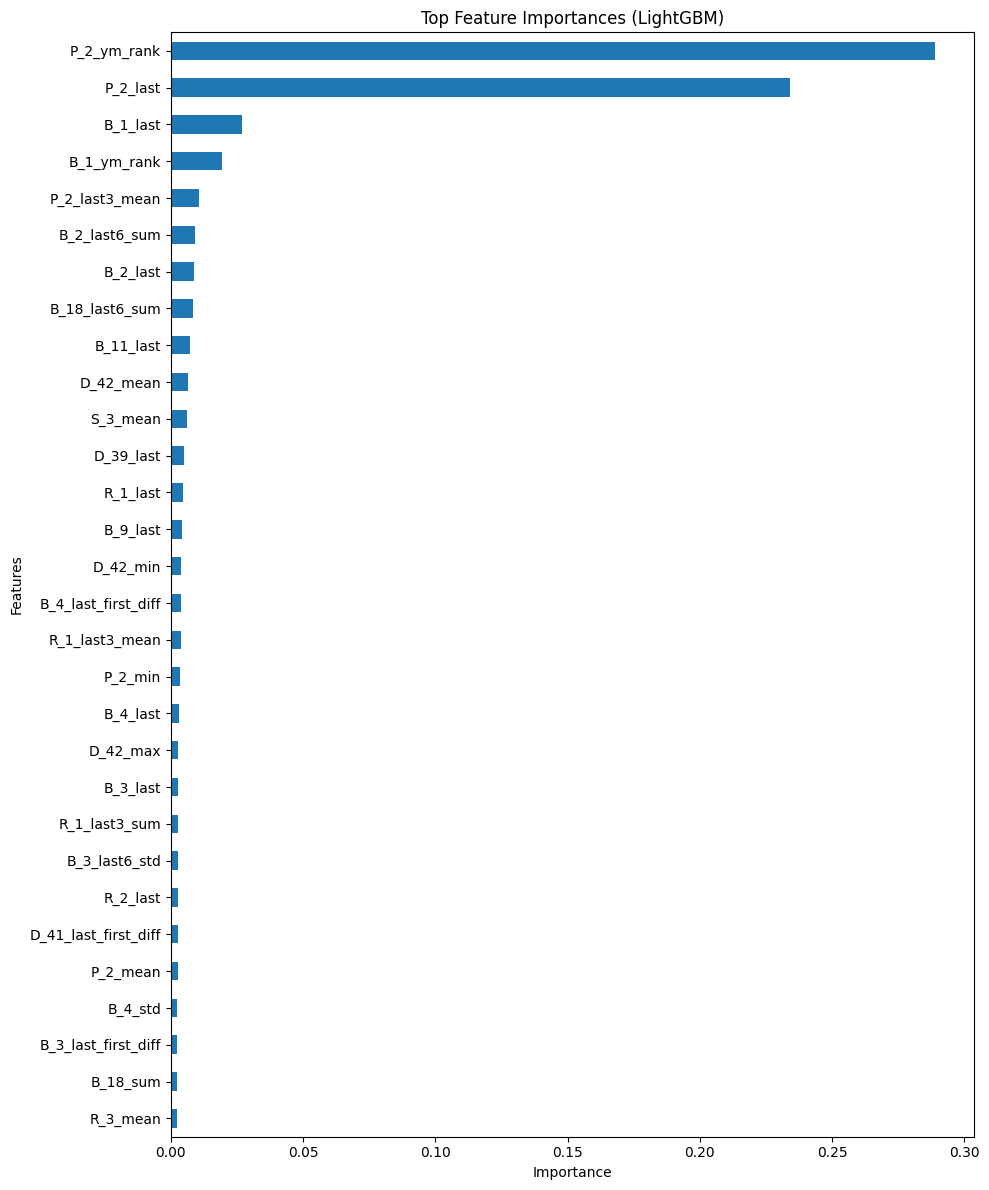

In [8]:
# average importance
importance = pd.Series(
    np.mean(importances, axis=0),
    index=feature_names
).sort_values(ascending=False)

top_n = 30

plt.figure(figsize=(10,12))
importance.head(top_n)[::-1].plot(kind="barh")

plt.title("Top Feature Importances (LightGBM)")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [9]:
release_memory()

In [10]:
SAVE_DIR = "/kaggle/working/models"
os.makedirs(SAVE_DIR, exist_ok=True)

cp.dump(scores, open(f"{SAVE_DIR}/cv_scores.pkl", "wb"))

for fold, model in enumerate(final_models):
    with open(f"{SAVE_DIR}/lgbm_fold_{fold}.pkl", "wb") as f:
        cp.dump(model, f)

In [11]:
del X, y
release_memory()

In [12]:
test = pl.read_parquet("/kaggle/input/datasets/analyticgentleman/gold-data/test_data")

test_ids = test["customer_ID"].to_numpy()
X_test = test.select(pl.exclude("customer_ID")).to_numpy()

del test
release_memory()

In [13]:
test_preds = np.zeros(len(X_test))

for model in final_models:
    test_preds += model.predict(X_test, raw_score=True) / len(final_models)

submission = pd.DataFrame({
    "customer_ID": test_ids,
    "prediction": test_preds
})

submission.to_csv("submission.csv", index=False)